Random search: 200/200 complete

  Rank 1  |  Cost = 3.6878
                KsZ = 0.333896
                 mZ = 0.038616
          sigma_log = 0.074328
          gge_small = 0.303852
          gge_large = 0.054573
          fish_rate = 0.769009

        micro_phyto:  1.22642  (7.85x obs)
         nano_phyto:  0.04292  (0.35x obs)
         pico_phyto:  0.09528  (0.54x obs)
          zoo_gt200:  0.06056  (1.02x obs)
          zoo_gt500:  0.01840  (0.56x obs)
                NO3:  79.65374  (39.51x obs)

  Rank 2  |  Cost = 3.7363
                KsZ = 0.618172
                 mZ = 0.130503
          sigma_log = 0.146776
          gge_small = 0.339318
          gge_large = 0.179073
          fish_rate = 0.492886

        micro_phyto:  0.26741  (1.71x obs)
         nano_phyto:  0.01483  (0.12x obs)
         pico_phyto:  0.32020  (1.83x obs)
          zoo_gt200:  0.03329  (0.56x obs)
          zoo_gt500:  0.00097  (0.03x obs)
                NO3:  0.49253  (0.24x obs)

  Rank 3  |  Cost =

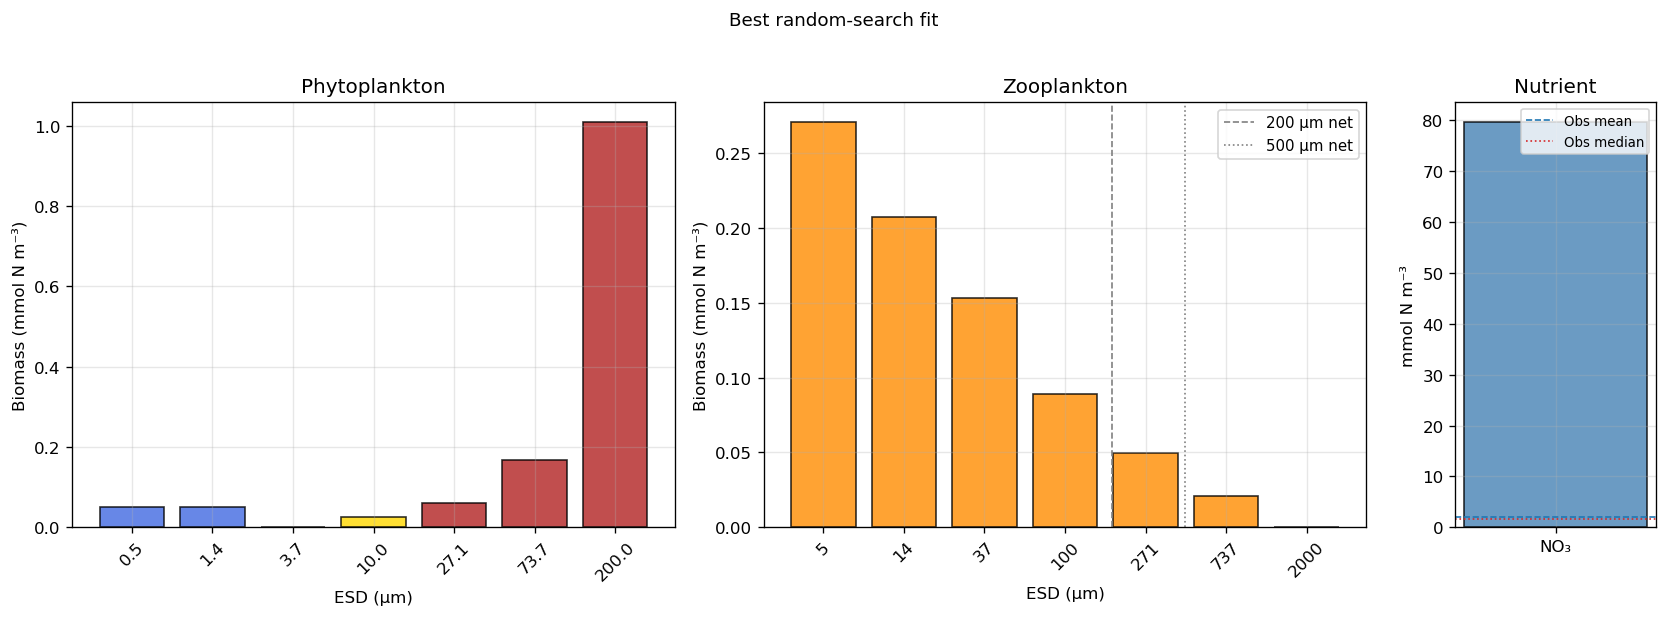

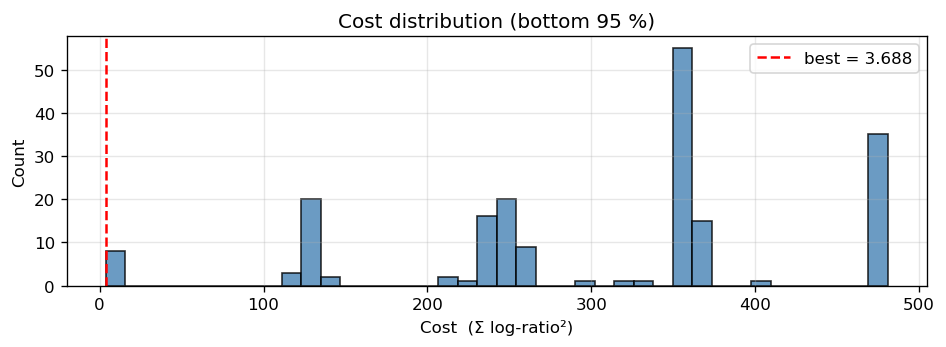

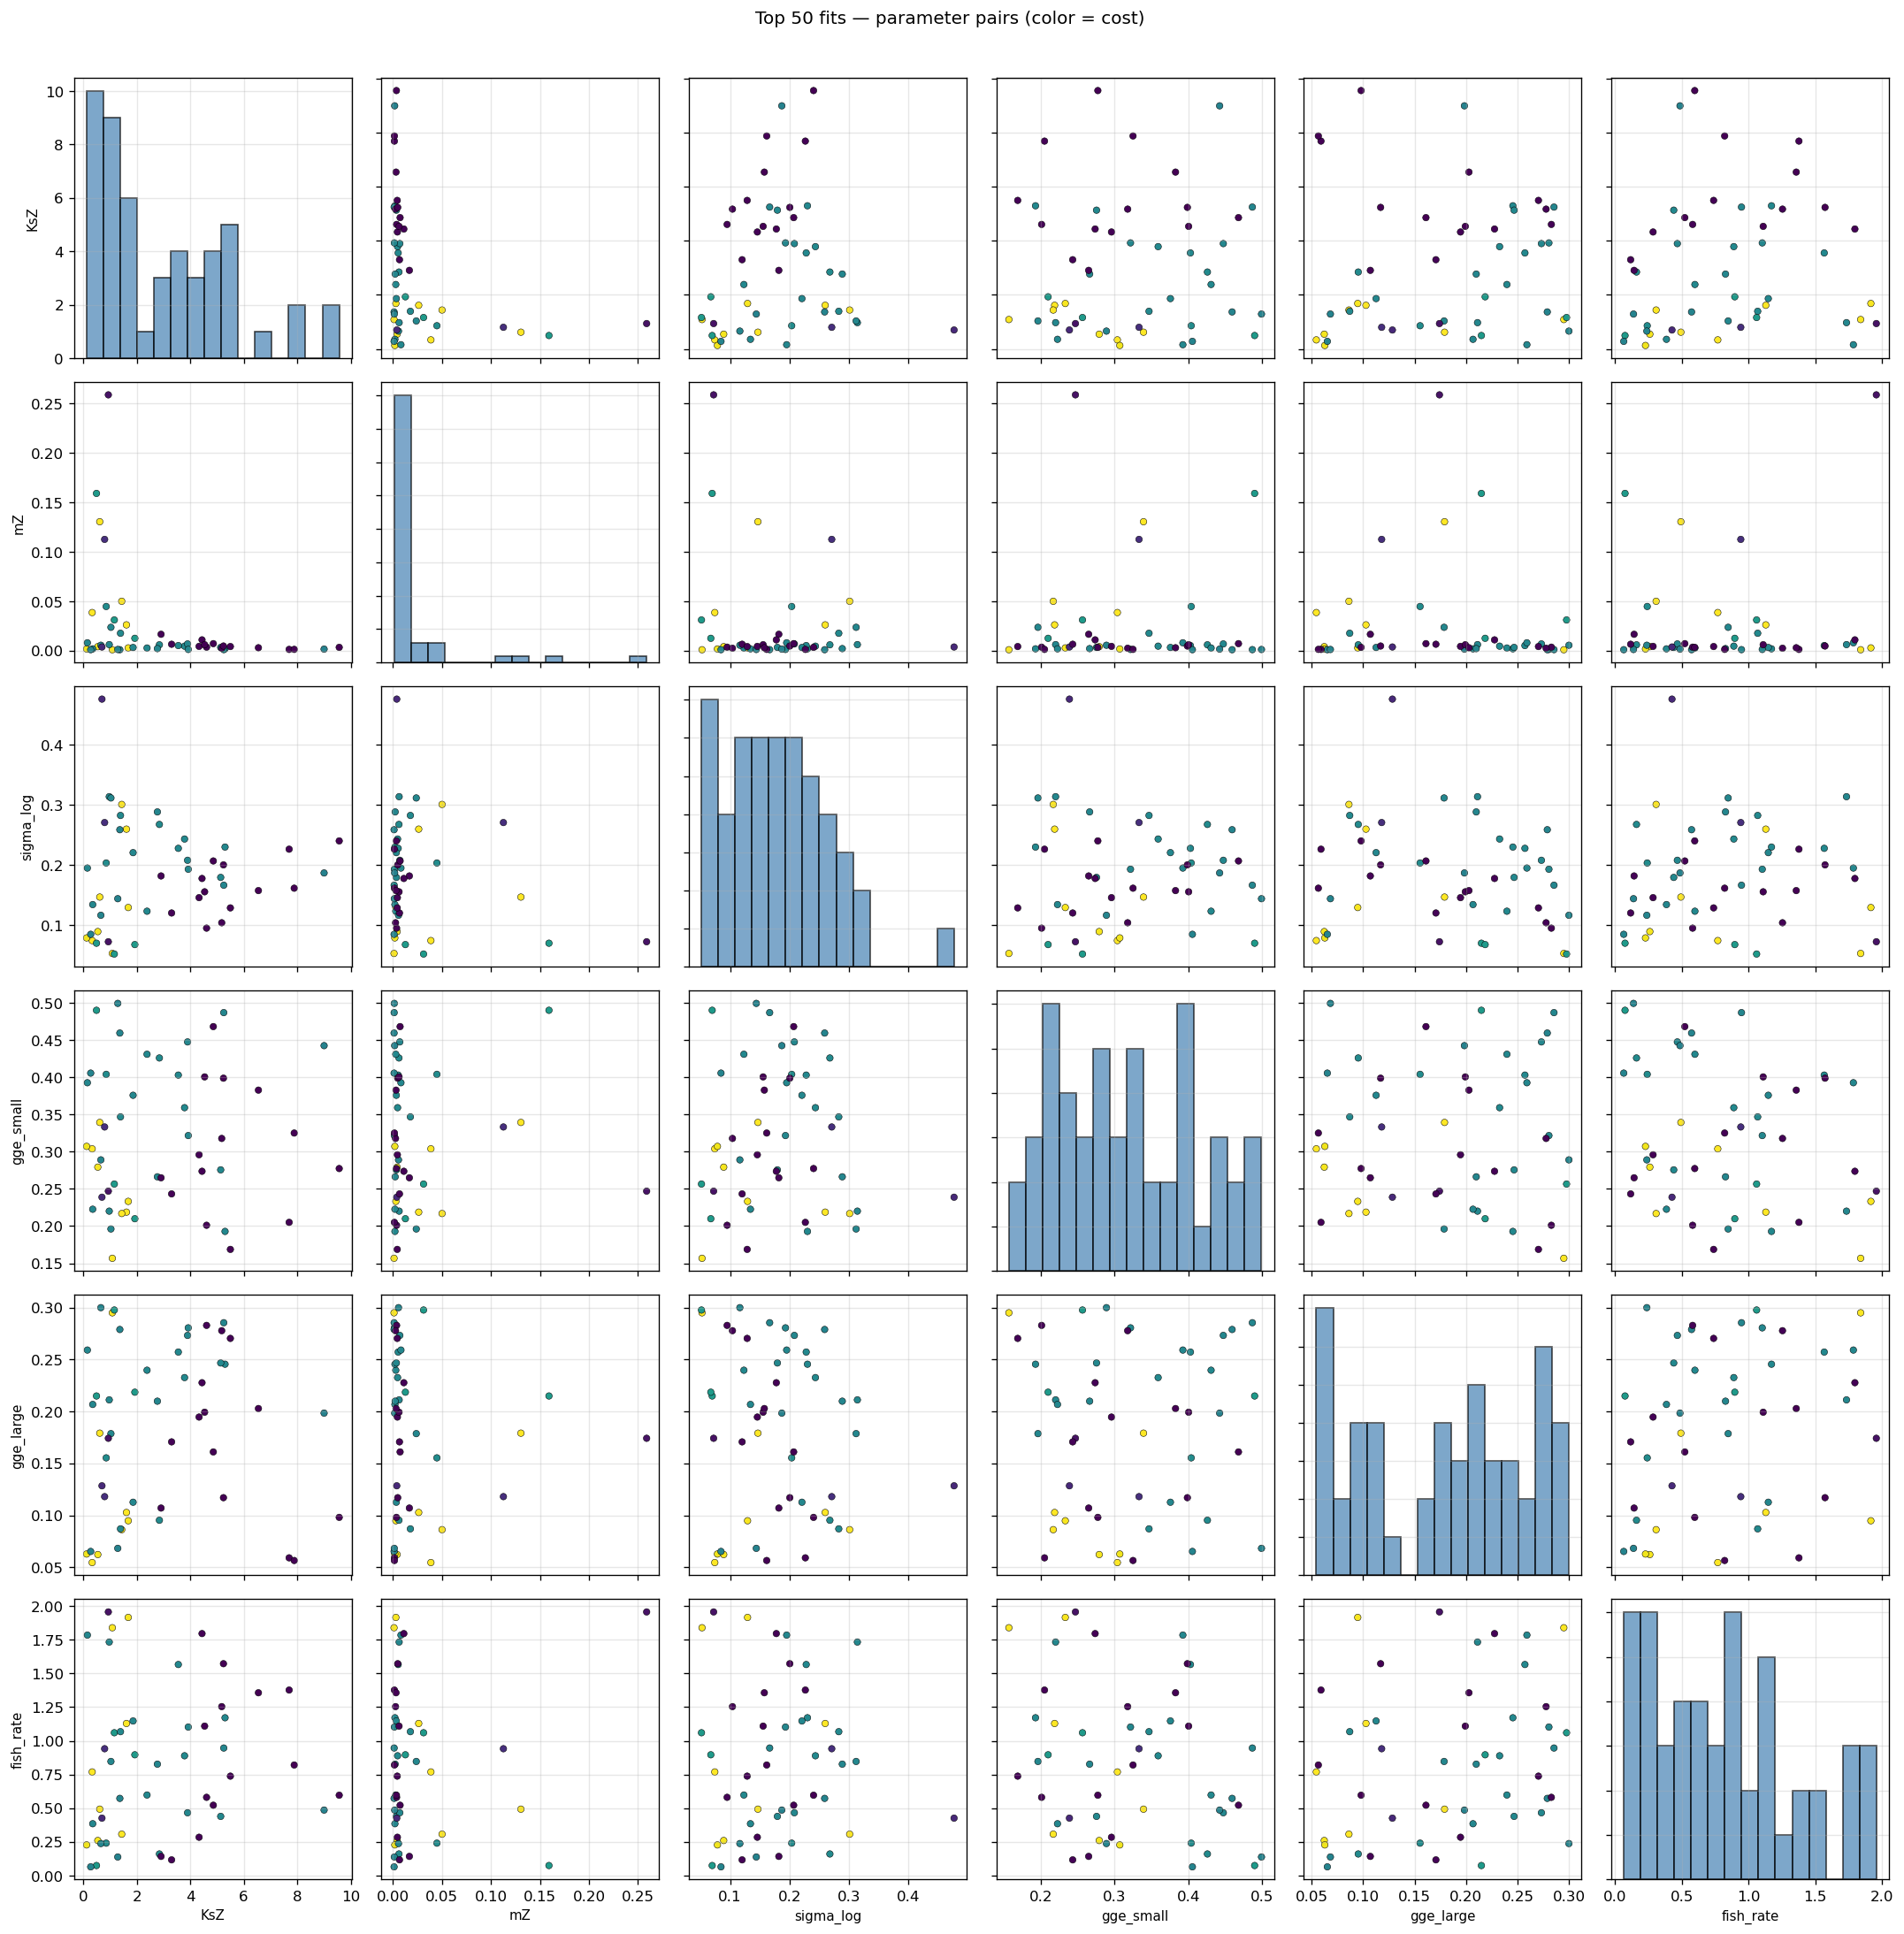

In [1]:
# %% [markdown]
# # Random Parameter Search
#
# Sample multiple parameters simultaneously using Latin-Hypercube
# sampling to find promising regions of parameter space.

# %% ── Imports ───────────────────────────────────────────────────────
import numpy as np
from cariaco_scan_utils import (
    PARAM_DEFS,
    generate_random_samples, run_parameter_samples,
    plot_spectrum, print_top_fits, print_fit_summary,
)

# %% ── Define search space ──────────────────────────────────────────
#
#  Include only the parameters you want to vary.
#  Everything else stays at the CARIACO baseline.
#  Format:  'param_name': (lo, hi)

search_space = {
    'KsZ':        (0.1, 10.0),
    'mZ':         (0.001, 0.3),
    'sigma_log':  (0.05, 0.5),
    'gge_small':  (0.15, 0.5),
    'gge_large':  (0.05, 0.3),
    'fish_rate':  (0.001, 2.0),
}

# Parameters to sample in log-space (useful when range spans decades)
LOG_PARAMS = ['mZ', 'fish_rate']

N_SAMPLES = 200
N_PROCS   = 20
SEED      = None # 42          # set to None for non-reproducible runs

# %% ── Generate samples ─────────────────────────────────────────────
samples = generate_random_samples(
    search_space,
    n=N_SAMPLES,
    seed=SEED,
    log_params=LOG_PARAMS,
    method='lhs',        # 'lhs' or 'random'
)

print(f"Generated {len(samples)} samples over {len(search_space)} parameters.")
print(f"Example sample: {samples[0]}")

# %% ── Run all samples ──────────────────────────────────────────────
results = run_parameter_samples(samples, n_procs=N_PROCS, label='Random search')

# filter out failures
valid   = [r for r in results if np.isfinite(r['cost'])]
failed  = len(results) - len(valid)
if failed:
    print(f"\n{failed}/{len(results)} runs failed (cost = inf)")

# %% ── Top fits ──────────────────────────────────────────────────────
print_top_fits(valid, n=10)

# %% ── Best-fit spectrum ────────────────────────────────────────────
best = min(valid, key=lambda r: r['cost'])
print_fit_summary(best)
plot_spectrum(best, title='Best random-search fit')

# %% ── Cost distribution ────────────────────────────────────────────
import matplotlib.pyplot as plt

costs = np.array([r['cost'] for r in valid])

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(costs[costs < np.percentile(costs, 95)], bins=40,
        color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(costs.min(), color='red', ls='--', label=f'best = {costs.min():.3f}')
ax.set_xlabel('Cost  (Σ log-ratio²)')
ax.set_ylabel('Count')
ax.set_title('Cost distribution (bottom 95 %)')
ax.legend()
plt.tight_layout()
plt.show()

# %% ── Parameter scatter (top fits) ─────────────────────────────────
#
#  Pairs plot colored by cost — helps identify which parameters
#  matter most and whether they interact.

top_n = 50
top = sorted(valid, key=lambda r: r['cost'])[:top_n]
param_names = list(search_space.keys())
n_par = len(param_names)

fig, axes = plt.subplots(n_par, n_par, figsize=(3 * n_par, 3 * n_par))
c_vals = np.array([r['cost'] for r in top])
c_norm = (c_vals - c_vals.min()) / (c_vals.max() - c_vals.min() + 1e-12)

for row in range(n_par):
    for col in range(n_par):
        ax = axes[row, col]
        x = [r['params'][param_names[col]] for r in top]
        y = [r['params'][param_names[row]] for r in top]

        if row == col:
            ax.hist(x, bins=15, color='steelblue', alpha=0.7, edgecolor='k')
        else:
            sc = ax.scatter(x, y, c=c_vals, cmap='viridis_r', s=20,
                            edgecolor='k', linewidth=0.3)

        if col == 0:
            ax.set_ylabel(param_names[row], fontsize=9)
        if row == n_par - 1:
            ax.set_xlabel(param_names[col], fontsize=9)
        if row != n_par - 1:
            ax.set_xticklabels([])
        if col != 0:
            ax.set_yticklabels([])

fig.suptitle(f'Top {top_n} fits — parameter pairs (color = cost)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# %% ── Imports ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from cariaco_scan_utils import (
    generate_random_samples, run_parameter_samples,
    plot_spectrum, print_top_fits, print_fit_summary,
)

# %% ── Search space ─────────────────────────────────────────────────
search_space = {
    'KsZ':          (0.1, 10.0),
    'mZ':           (0.001, 0.5),
    'fish_rate':    (0.001, 1.0),
}

LOG_PARAMS = ['mZ', 'fish_rate']   # sample in log-space
N_SAMPLES  = 200
N_PROCS    = 20
SEED       = 42

# %% ── Generate & run ───────────────────────────────────────────────
samples = generate_random_samples(
    search_space, n=N_SAMPLES, seed=SEED,
    log_params=LOG_PARAMS, method='lhs',
)
results = run_parameter_samples(samples, n_procs=N_PROCS, label='Random search')

valid  = [r for r in results if np.isfinite(r['cost'])]
failed = len(results) - len(valid)
if failed:
    print(f"{failed}/{len(results)} runs failed")

# %% ── Results ───────────────────────────────────────────────────────
print_top_fits(valid, n=10)

best = min(valid, key=lambda r: r['cost'])
print_fit_summary(best)
plot_spectrum(best, title='Best random-search fit')

# %% ── Cost distribution ────────────────────────────────────────────
costs = np.array([r['cost'] for r in valid])
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(costs[costs < np.percentile(costs, 95)], bins=40,
        color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(costs.min(), color='red', ls='--', label=f'best = {costs.min():.3f}')
ax.set_xlabel('Cost  (Σ log-ratio²)')
ax.set_ylabel('Count')
ax.set_title('Cost distribution (bottom 95 %)')
ax.legend()
plt.tight_layout()
plt.show()

# %% ── Parameter pairs plot ─────────────────────────────────────────
top_n = 50
top = sorted(valid, key=lambda r: r['cost'])[:top_n]
param_names = list(search_space.keys())
n_par = len(param_names)

fig, axes = plt.subplots(n_par, n_par, figsize=(3*n_par, 3*n_par))
c_vals = np.array([r['cost'] for r in top])

for row in range(n_par):
    for col in range(n_par):
        ax = axes[row, col]
        x = [r['params'][param_names[col]] for r in top]
        y = [r['params'][param_names[row]] for r in top]
        if row == col:
            ax.hist(x, bins=15, color='steelblue', alpha=0.7, edgecolor='k')
        else:
            ax.scatter(x, y, c=c_vals, cmap='viridis_r', s=20,
                       edgecolor='k', linewidth=0.3)
        if col == 0:
            ax.set_ylabel(param_names[row], fontsize=9)
        if row == n_par - 1:
            ax.set_xlabel(param_names[col], fontsize=9)
        if row != n_par - 1:
            ax.set_xticklabels([])
        if col != 0:
            ax.set_yticklabels([])

fig.suptitle(f'Top {top_n} fits — parameter pairs (color = cost)', y=1.01)
plt.tight_layout()
plt.show()